# Matching Pipeline on Smaller Sample (Exclude Cohort 2017)

This notebook rebuilds the matching workflow from scratch after removing treated hospitals in merger cohort 2017.

## Matching Overview

This notebook rebuilds the matched sample using a tighter treated set by excluding merger cohort 2017. The goal is to produce a cleaner treated-control comparison before downstream DiD and event-study estimation.

## Design Context

Matching is performed at the hospital level using pre-treatment summaries and exact cohort constraints. We apply 1:1 nearest-neighbor Mahalanobis matching without replacement so each treated hospital is paired with a single distinct never-treated control from the same cohort stratum.

## Objectives

- Remove treated hospitals in merger cohort 2017
- Construct pre-treatment features over a fixed PRE_YEARS window
- Run exact-cohort Mahalanobis 1:1 matching without replacement
- Evaluate balance improvements with standardized mean differences
- Export the matched hospital-year panel for analysis

## Dataset Description

The notebook reads ../01_data/hospital_analysis.csv and keeps hospital-year variables needed for feature construction, matching, and output panel reconstruction.

## Output

The final matched panel is saved to smaller_dataset/matched_sample.csv and is ready for parallel-trends checks and final DiD modeling on the smaller sample.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

## Step 1 - Load Data

In [ ]:
DATA_PATH = "../01_data/hospital_analysis.csv"
keep_cols = [
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "merger_year",
    "years_to_merger",
    "cost_per_discharge",
    "total_operating_costs",
    "total_discharges",
    "PRVDR_CTRL_TYPE_CD",
    "hrrcode",
    "fac_name",
]
num_cols = [
    "fiscal_year",
    "treated",
    "merger_year",
    "years_to_merger",
    "cost_per_discharge",
    "total_operating_costs",
    "total_discharges",
]
df = pd.read_csv(DATA_PATH, usecols=keep_cols).copy()
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
df["PRVDR_NUM"] = df["PRVDR_NUM"].astype(str).str.strip()
df = df.dropna(
    subset=[
        "PRVDR_NUM",
        "fiscal_year",
        "treated",
        "cost_per_discharge",
        "total_operating_costs",
        "total_discharges",
    ]
)
df = df[df["treated"].isin([0, 1])].copy()
df = df[
    (df["cost_per_discharge"] >= 0)
    & (df["total_operating_costs"] >= 0)
    & (df["total_discharges"] >= 0)
].copy()
print("Loaded shape:", df.shape)
df.head()

Loaded shape: (53354, 11)


,fiscal_year,PRVDR_NUM,PRVDR_CTRL_TYPE_CD,total_operating_costs,total_discharges,cost_per_discharge,fac_name,hrrcode,merger_year,treated,years_to_merger
0,2011,271326,2,8661723.0,155.0,55882.083871,BEARTOOTH BILLINGS CLINIC,274.0,NaN,0,NaN
1,2011,13025,4,39554420.0,2390.0,16549.966527,NaN,NaN,NaN,0,NaN
2,2011,103037,4,20242022.0,1370.0,14775.198540,NaN,NaN,NaN,0,NaN
3,2011,103042,4,26136744.0,1495.0,17482.771906,NaN,NaN,NaN,0,NaN
4,2011,141990,1,116445.0,11.0,10585.909091,NaN,NaN,NaN,0,NaN


## Step 2 - Remove Problematic Cohort (2017)

In [ ]:
hospital_treat_status = df.groupby("PRVDR_NUM", as_index=False)["treated"].max()
treated_ids_all = set(
    hospital_treat_status.loc[hospital_treat_status["treated"] == 1, "PRVDR_NUM"]
)
never_treated_ids = set(
    hospital_treat_status.loc[hospital_treat_status["treated"] == 0, "PRVDR_NUM"]
)
treated_merger_year_all = (
    df[(df["PRVDR_NUM"].isin(treated_ids_all)) & df["merger_year"].notna()]
    .groupby("PRVDR_NUM", as_index=False)["merger_year"]
    .min()
    .rename(columns={"merger_year": "first_merger_year"})
)
treated_merger_year_all["first_merger_year"] = treated_merger_year_all[
    "first_merger_year"
].astype(int)
treated_merger_year = treated_merger_year_all[
    treated_merger_year_all["first_merger_year"] != 2017
].copy()
treated_ids = set(treated_merger_year["PRVDR_NUM"])
df_small = df[
    (df["PRVDR_NUM"].isin(treated_ids)) | (df["PRVDR_NUM"].isin(never_treated_ids))
].copy()
print("Treated hospitals before removal:", len(treated_ids_all))
print("Treated hospitals after removing cohort 2017:", len(treated_ids))
print(
    "Remaining treated cohorts:",
    sorted(treated_merger_year["first_merger_year"].unique().tolist()),
)

Treated hospitals before removal: 1242
Treated hospitals after removing cohort 2017: 1137
Remaining treated cohorts: [2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019]


## Step 3 - Build Pre-Treatment Features (PRE_YEARS = 2)

In [4]:
PRE_YEARS = 2
id_col = "PRVDR_NUM"
treated_cohorts = sorted(treated_merger_year["first_merger_year"].unique().tolist())
print("PRE_YEARS:", PRE_YEARS)
print("Treated cohorts used for matching:", treated_cohorts)

PRE_YEARS: 2
Treated cohorts used for matching: [2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019]


In [ ]:
def pre_feature_row(group_df, cohort_year):
    start_year = cohort_year - PRE_YEARS
    end_year = cohort_year - 1
    pre = group_df[
        (group_df["fiscal_year"] >= start_year) & (group_df["fiscal_year"] <= end_year)
    ].copy()
    n_pre_years = pre["fiscal_year"].nunique()
    if n_pre_years < 2:
        return None
    year_mean = pre.groupby("fiscal_year", as_index=False)["cost_per_discharge"].mean()
    slope = (
        float(
            np.polyfit(year_mean["fiscal_year"], year_mean["cost_per_discharge"], 1)[0]
        )
        if year_mean["fiscal_year"].nunique() >= 2
        else np.nan
    )
    return {
        "pre_mean_cost_per_discharge": pre["cost_per_discharge"].mean(),
        "pre_trend_cost_per_discharge": slope,
        "pre_mean_total_operating_costs": pre["total_operating_costs"].mean(),
        "pre_mean_total_discharges": pre["total_discharges"].mean(),
        "n_pre_years": n_pre_years,
    }

In [ ]:
treated_rows = []
dropped_treated_insufficient_pre = 0
treated_map = dict(
    zip(treated_merger_year["PRVDR_NUM"], treated_merger_year["first_merger_year"])
)
for hosp_id, cohort in treated_map.items():
    g = df_small[df_small[id_col] == hosp_id]
    feats = pre_feature_row(g, int(cohort))
    if feats is None:
        dropped_treated_insufficient_pre += 1
        continue
    feats.update({id_col: hosp_id, "merger_cohort": int(cohort), "treated_hospital": 1})
    treated_rows.append(feats)
treated_features = pd.DataFrame(treated_rows)
print(
    "Dropped treated hospitals for insufficient pre-years:",
    dropped_treated_insufficient_pre,
)
print("Treated feature rows:", treated_features.shape)
treated_features.head()

Dropped treated hospitals for insufficient pre-years: 247
Treated feature rows: (890, 8)


,pre_mean_cost_per_discharge,pre_trend_cost_per_discharge,pre_mean_total_operating_costs,pre_mean_total_discharges,n_pre_years,PRVDR_NUM,merger_cohort,treated_hospital
0,20804.903155,-1106.509013,83996933.5,4043.0,2,100014,2016,1
1,15805.508771,200.508056,172101340.0,10888.5,2,100023,2014,1
2,15204.279098,607.027657,245271003.0,16147.0,2,100032,2013,1
3,12339.602090,-65.817416,59859706.5,4850.5,2,100043,2014,1
4,17808.157778,347.670972,473691029.5,26597.0,2,100044,2019,1


In [ ]:
control_rows = []
for hosp_id, g in df_small[df_small[id_col].isin(never_treated_ids)].groupby(id_col):
    for cohort in treated_cohorts:
        feats = pre_feature_row(g, int(cohort))
        if feats is None:
            continue
        feats.update(
            {id_col: hosp_id, "merger_cohort": int(cohort), "treated_hospital": 0}
        )
        control_rows.append(feats)
control_features = pd.DataFrame(control_rows)
print("Control feature rows:", control_features.shape)
control_features.head()

Control feature rows: (27209, 8)


,pre_mean_cost_per_discharge,pre_trend_cost_per_discharge,pre_mean_total_operating_costs,pre_mean_total_discharges,n_pre_years,PRVDR_NUM,merger_cohort,treated_hospital
0,15994.897913,1902.219857,429012636.0,26913.0,2,100001,2013,0
1,15054.011107,-3783.993468,385374467.5,25631.0,2,100001,2014,0
2,16277.650000,6231.271255,410651223.5,25333.0,2,100001,2015,0
3,19227.564318,-331.442619,516794566.5,26896.0,2,100001,2016,0
4,20761.962060,688.377975,619201831.0,29810.0,2,100001,2018,0


## Step 4 - Build Matching Dataset

In [ ]:
continuous_covariates = [
    "pre_mean_cost_per_discharge",
    "pre_trend_cost_per_discharge",
    "pre_mean_total_operating_costs",
    "pre_mean_total_discharges",
    "n_pre_years",
]
match_df = pd.concat([treated_features, control_features], ignore_index=True)
match_df = (
    match_df[[id_col, "treated_hospital", "merger_cohort"] + continuous_covariates]
    .dropna()
    .copy()
)
scaler = StandardScaler()
match_design = match_df.copy()
match_design[continuous_covariates] = scaler.fit_transform(
    match_design[continuous_covariates]
)
print("Matching dataset shape:", match_design.shape)
match_design.head()

Matching dataset shape: (28099, 8)


,PRVDR_NUM,treated_hospital,merger_cohort,pre_mean_cost_per_discharge,pre_trend_cost_per_discharge,pre_mean_total_operating_costs,pre_mean_total_discharges,n_pre_years
0,100014,1,2016,-0.080371,-0.002408,-0.219902,-0.159386,0.0
1,100023,1,2014,-0.087304,-0.000570,0.075452,0.611142,0.0
2,100032,1,2013,-0.088138,0.000001,0.320739,1.203038,0.0
3,100043,1,2014,-0.092111,-0.000945,-0.300818,-0.068494,0.0
4,100044,1,2019,-0.084527,-0.000363,1.086475,2.379289,0.0


## Step 5 - Mahalanobis Matching

In [ ]:
def mahalanobis_matrix(X_t, X_c):
    X_pool = np.vstack([X_t, X_c])
    cov = np.cov(X_pool, rowvar=False)
    VI = np.linalg.pinv(cov)
    return cdist(X_t, X_c, metric="mahalanobis", VI=VI)


def match_no_replacement_exact_cohort(df_design, feature_cols):
    matches = []
    used_controls = set()
    for cohort in sorted(df_design["merger_cohort"].unique()):
        d = df_design[df_design["merger_cohort"] == cohort].copy()
        t = d[d["treated_hospital"] == 1].copy()
        c = d[(d["treated_hospital"] == 0) & (~d[id_col].isin(used_controls))].copy()
        if t.empty or c.empty:
            continue
        X_t = t[feature_cols].to_numpy()
        X_c = c[feature_cols].to_numpy()
        D = mahalanobis_matrix(X_t, X_c)
        available = list(range(c.shape[0]))
        for i in range(t.shape[0]):
            if not available:
                break
            j_local = int(np.argmin(D[i, available]))
            j = available[j_local]
            t_id = t.iloc[i][id_col]
            c_id = c.iloc[j][id_col]
            matches.append(
                {
                    "merger_cohort": int(cohort),
                    "treated_hospital_id": t_id,
                    "control_hospital_id": c_id,
                    "distance": float(D[i, j]),
                }
            )
            used_controls.add(c_id)
            available.remove(j)
    return pd.DataFrame(matches)

In [ ]:
matches_no_replace = match_no_replacement_exact_cohort(
    match_design, continuous_covariates
)
matched_pairs = matches_no_replace[
    ["treated_hospital_id", "control_hospital_id", "distance"]
].rename(
    columns={"treated_hospital_id": "treated_id", "control_hospital_id": "control_id"}
)
print("Matched pairs count:", matched_pairs.shape[0])
matched_pairs.head()

Matched pairs count: 890


,treated_id,control_id,distance
0,100032,440053,0.012794
1,100052,210016,0.038077
2,100067,450675,0.023852
3,100073,50309,0.100345
4,100075,450015,1.103468


## Step 6 - Diagnostics (SMD Before vs After)

In [ ]:
def smd_table(df_t, df_c, covariates):
    rows = []
    for v in covariates:
        mt = df_t[v].mean()
        mc = df_c[v].mean()
        vt = df_t[v].var(ddof=1)
        vc = df_c[v].var(ddof=1)
        denom = np.sqrt((vt + vc) / 2)
        smd = (mt - mc) / denom if denom > 0 else np.nan
        rows.append(
            {
                "covariate": v,
                "mean_treated": mt,
                "mean_control": mc,
                "smd": smd,
                "abs_smd": abs(smd),
            }
        )
    return pd.DataFrame(rows)

In [ ]:
before_t = match_df[match_df["treated_hospital"] == 1].copy()
before_c = match_df[match_df["treated_hospital"] == 0].copy()
matched_t_ids = set(matches_no_replace["treated_hospital_id"])
matched_c_ids = set(matches_no_replace["control_hospital_id"])
after_t = match_df[
    (match_df["treated_hospital"] == 1) & (match_df[id_col].isin(matched_t_ids))
].copy()
after_c = match_df[
    (match_df["treated_hospital"] == 0) & (match_df[id_col].isin(matched_c_ids))
].copy()
smd_before = smd_table(before_t, before_c, continuous_covariates).rename(
    columns={"smd": "smd_before", "abs_smd": "abs_smd_before"}
)
smd_after = smd_table(after_t, after_c, continuous_covariates).rename(
    columns={"smd": "smd_after", "abs_smd": "abs_smd_after"}
)
balance_summary = smd_before[
    ["covariate", "mean_treated", "mean_control", "smd_before", "abs_smd_before"]
].merge(
    smd_after[["covariate", "smd_after", "abs_smd_after"]], on="covariate", how="left"
)
print(
    "Counts before matching: treated=", before_t.shape[0], "control=", before_c.shape[0]
)
print("Counts after matching: treated=", after_t.shape[0], "control=", after_c.shape[0])
balance_summary.sort_values("abs_smd_before", ascending=False)

Counts before matching: treated= 890 control= 27209
Counts after matching: treated= 890 control= 5200


,covariate,mean_treated,mean_control,smd_before,abs_smd_before,smd_after,abs_smd_after
3,pre_mean_total_discharges,7.313608e+03,5.398348e+03,0.219781,0.219781,-0.011595,0.011595
0,pre_mean_cost_per_discharge,3.201348e+04,8.029008e+04,-0.093096,0.093096,-0.038575,0.038575
2,pre_mean_total_operating_costs,1.701008e+08,1.489233e+08,0.081558,0.081558,-0.023876,0.023876
1,pre_trend_cost_per_discharge,1.380373e+03,5.807465e+02,0.001565,0.001565,-0.026531,0.026531
4,n_pre_years,2.000000e+00,2.000000e+00,NaN,NaN,NaN,NaN


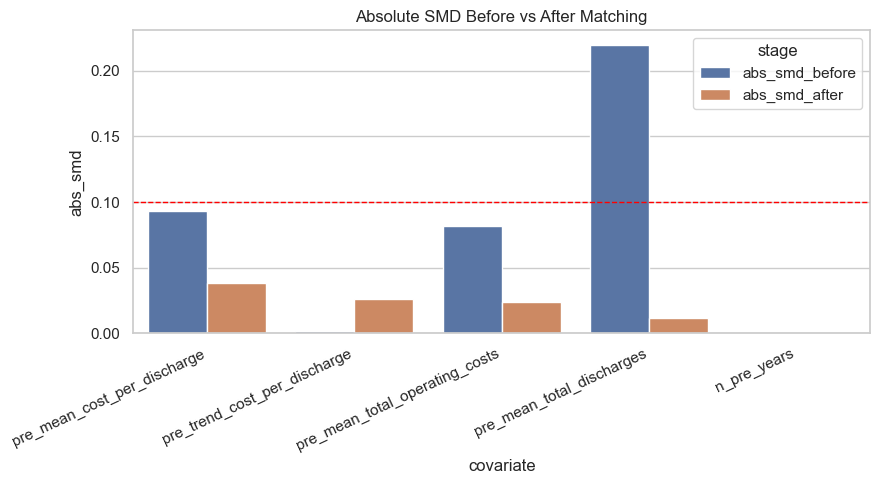

In [ ]:
plot_balance = balance_summary[["covariate", "abs_smd_before", "abs_smd_after"]].melt(
    id_vars="covariate", var_name="stage", value_name="abs_smd"
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_balance, x="covariate", y="abs_smd", hue="stage")
plt.axhline(0.1, color="red", linestyle="--", linewidth=1)
plt.title("Absolute SMD Before vs After Matching")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Step 7 - Save Outputs

In [14]:
matched_ids = matched_t_ids.union(matched_c_ids)
matched_panel = df_small[df_small[id_col].isin(matched_ids)].copy()
OUT_PATH = "../smaller_dataset/matched_sample.csv"
matched_panel.to_csv(OUT_PATH, index=False)
print("Saved matched panel to:", OUT_PATH)
print("Matched panel shape:", matched_panel.shape)
matched_panel.head()

Saved matched panel to: ../smaller_dataset/matched_sample.csv
Matched panel shape: (16071, 11)


,fiscal_year,PRVDR_NUM,PRVDR_CTRL_TYPE_CD,total_operating_costs,total_discharges,cost_per_discharge,fac_name,hrrcode,merger_year,treated,years_to_merger
1,2011,13025,4,39554420.0,2390.0,16549.966527,NaN,NaN,NaN,0,NaN
3,2011,103042,4,26136744.0,1495.0,17482.771906,NaN,NaN,NaN,0,NaN
19,2011,513028,4,18453199.0,1120.0,16476.070536,NaN,NaN,NaN,0,NaN
27,2011,10169,2,16328100.0,1255.0,13010.438247,ATMORE COMMUNITY HOSPITAL,134.0,2015.0,1,-4.0
42,2011,521317,2,20371432.0,482.0,42264.381743,CALUMET MEDICAL CTR,446.0,2013.0,1,-2.0


## Summary of Findings

This notebook rebuilt the matching design on a smaller treated sample after excluding merger cohort 2017 and generated a matched hospital-year panel for downstream causal analysis.

### Design and Balance Evidence

- Matching used exact cohort constraints with 1:1 Mahalanobis nearest-neighbor matching without replacement.
- Pre-treatment covariates were constructed on a fixed pre-period window and used to align treated and control hospitals.
- Standardized mean-difference diagnostics were used to compare pre-match and post-match balance.

### Output and Readiness

- The final matched panel was exported to smaller_dataset/matched_sample.csv.
- The exported sample is structured for parallel-trends testing and final DiD/event-study estimation on the smaller cohort set.

### Interpretation

The smaller-sample matching workflow improves comparability by removing the problematic cohort and enforcing tighter pair construction rules, creating a more defensible analysis sample for identification checks.